# Głębokie Uczenie w Praktyce
## Laboratorium 7
### Mateusz Horczak

In [102]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from numpy import array, argmax
from tensorflow.keras import preprocessing
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, SimpleRNN, Dense, Input
import warnings
from numpy.exceptions import VisibleDeprecationWarning

warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)

#### Ćwiczenie 1a Uruchomienie kodu z RNN - Echo sequence prediction problem - przygotowanie danych

In [127]:
def generate_sequence(length, n_features):
    return [randint(0, n_features - 1) for _ in range(length)]

def one_hot_encode(sequence, n_features):
    encoding = list()
    for value in sequence:
        vector = [0 for _ in range(n_features)]
        vector[value] = 1
        encoding.append(vector)
    return array(encoding)

def one_hot_decode(encoded_seq):
    return [argmax(vector) for vector in encoded_seq]

def generate_example(length, n_features, out_index):
    sequence = generate_sequence(length, n_features)
    encoded = one_hot_encode(sequence, n_features)
    X = encoded.reshape((1, length, n_features))
    y = encoded[out_index].reshape(1, n_features)
    return X, y

In [128]:
seq1 = generate_sequence(5, 10)
print("Przykładowa sekwencja:", seq1)

Przykładowa sekwencja: [3, 8, 6, 8, 8]


In [129]:
one_hot_encode(seq1, 10)

array([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

#### Ćwiczenie 1b Uruchomienie kodu z RNN - Echo sequence prediction problem – budowa modelu, ewaluacja i predykcja

In [105]:
length = 5
n_features = 10
out_index = 2

model_echo = Sequential()
model_echo.add(Input(shape=(length, n_features)))
model_echo.add(LSTM(25))
model_echo.add(Dense(n_features, activation='softmax'))
model_echo.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [106]:
print("Struktura modelu dla problemu Echa:")
model_echo.summary()

Struktura modelu dla problemu Echa:


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 25)             │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,860 (15.08 KB)

 Trainable params: 3,860 (15.08 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
# Trening
for i in range(1000):
    X, y = generate_example(length, n_features, out_index)
    model_echo.fit(X, y, epochs=1, verbose=0)

In [108]:
# Predykcja
X, y = generate_example(length, n_features, out_index)
X_tensor = tf.cast(X, tf.float32)
yhat = model_echo.predict(X_tensor, verbose=0)

In [109]:
print('--- Wyniki predykcji ---')
seq_decoded = [int(x) for x in one_hot_decode(X[0])]
print('Sekwencja wejściowa:', seq_decoded)
print('Oczekiwana wartość (indeks 2):', int(one_hot_decode(y)[0]))
print('Przewidziana wartość:', int(one_hot_decode(yhat)[0]))

--- Wyniki predykcji ---
Sekwencja wejściowa: [2, 6, 1, 7, 5]
Oczekiwana wartość (indeks 2): 1
Przewidziana wartość: 9


#### Ćwiczenie 2 - Użycie SimpleRNN podczas klasyfikacji recenzji razem z warstwą Embedding

In [110]:
max_features = 10000  # Liczba analizowanych, najpopularniejszych słów
maxlen = 200          # Ucięcie recenzji do maxlen słów
embedding_dim = 32    # Wielkość wektora

# Pobranie danych
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Dopasowanie długości sekwencji do maxlen
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print(f"Kształt danych treningowych: {x_train.shape}")

Kształt danych treningowych: (25000, 200)


In [111]:
model_rnn = Sequential()
model_rnn.add(Input(shape=(maxlen,)))
model_rnn.add(Embedding(max_features, embedding_dim))
model_rnn.add(SimpleRNN(32))
model_rnn.add(Dense(1, activation='sigmoid'))
model_rnn.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

In [112]:
print("Struktura SimpleRNN:")
model_rnn.summary()

Struktura SimpleRNN:


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_30 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# Trening
history_rnn = model_rnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - acc: 0.6055 - loss: 0.6504 - val_acc: 0.7652 - val_loss: 0.4912
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.8058 - loss: 0.4375 - val_acc: 0.8304 - val_loss: 0.3998
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.8590 - loss: 0.3376 - val_acc: 0.6976 - val_loss: 0.7148
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.8880 - loss: 0.2792 - val_acc: 0.7660 - val_loss: 0.4943
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9177 - loss: 0.2148 - val_acc: 0.8450 - val_loss: 0.3879
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9444 - loss: 0.1556 - val_acc: 0.8308 - val_loss: 0.4300
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9638 - loss: 0.1080 - val_acc: 0.8492 - val_loss: 0.4379
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9777 - loss: 0.0721 - val_acc: 0.8400 - val_loss: 0.4901
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/

In [114]:
acc = history_rnn.history['acc']
val_acc = history_rnn.history['val_acc']
loss = history_rnn.history['loss']
val_loss = history_rnn.history['val_loss']
epochs_range = range(1, len(acc) + 1)

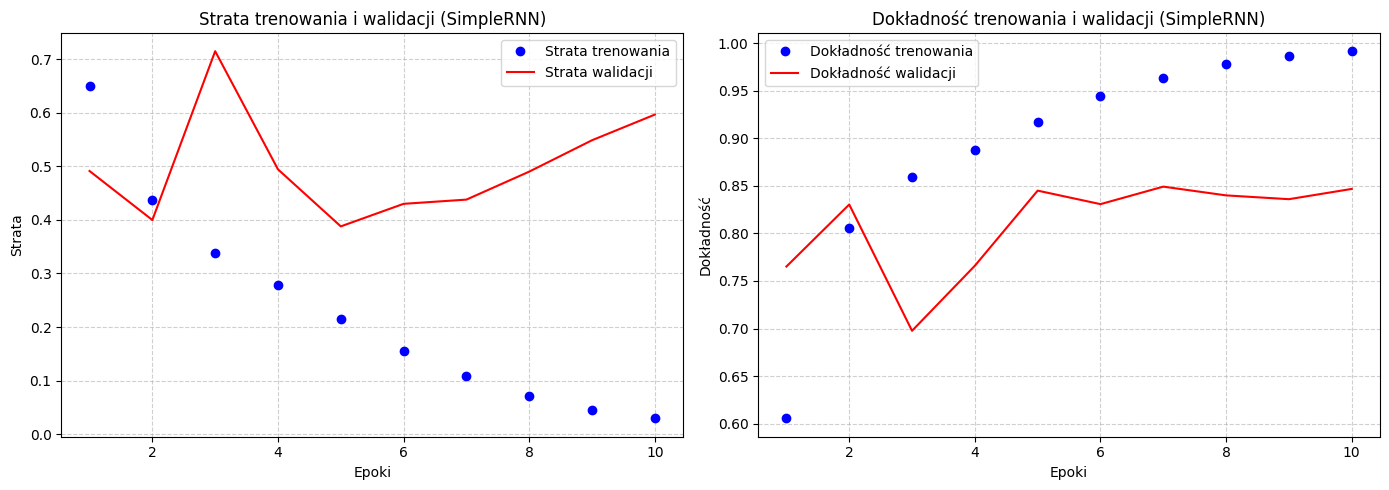

In [115]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'bo', label='Strata trenowania')
plt.plot(epochs_range, val_loss, 'r-', label='Strata walidacji')
plt.title('Strata trenowania i walidacji (SimpleRNN)')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'bo', label='Dokładność trenowania')
plt.plot(epochs_range, val_acc, 'r-', label='Dokładność walidacji')
plt.title('Dokładność trenowania i walidacji (SimpleRNN)')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Automatyzacja parametrów

--- maxlen=20, emb_dim=8 ---


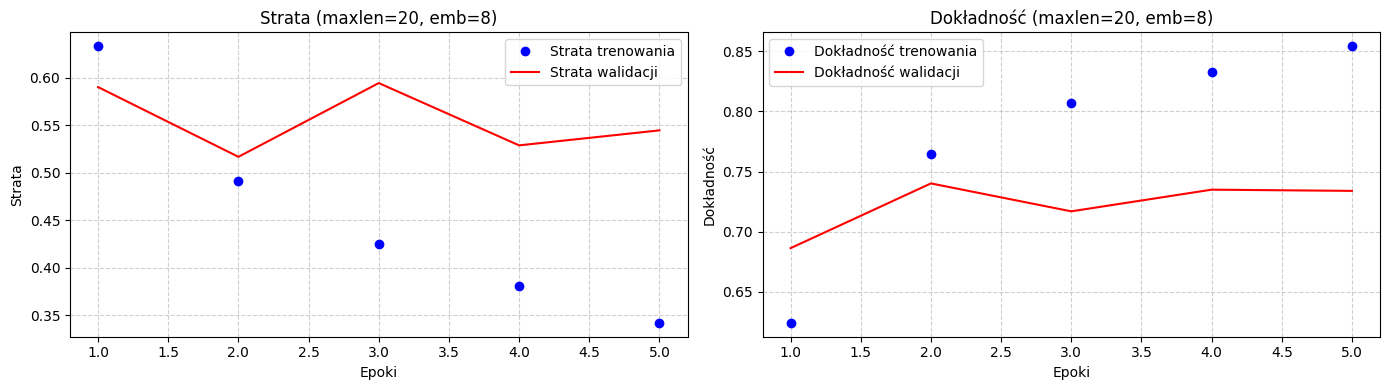

--- maxlen=20, emb_dim=32 ---


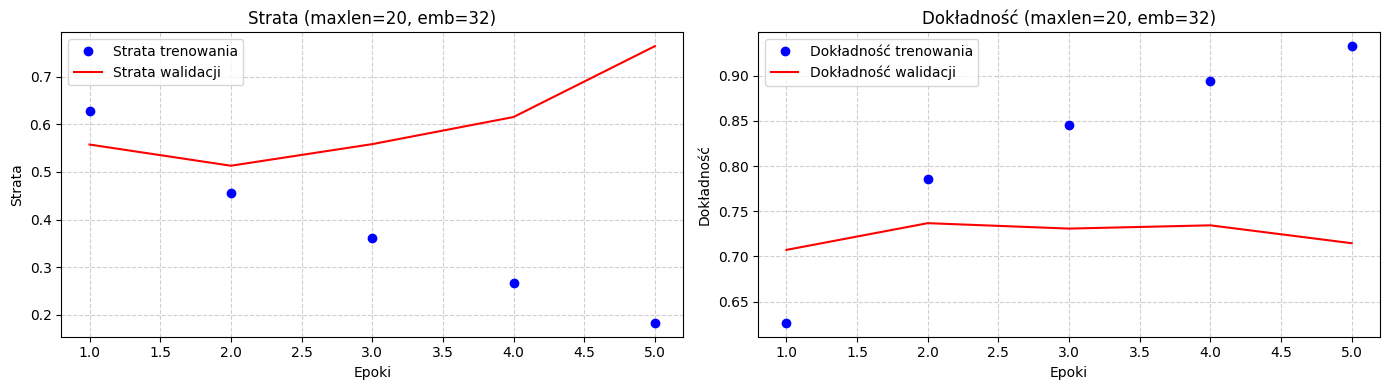

--- maxlen=20, emb_dim=64 ---


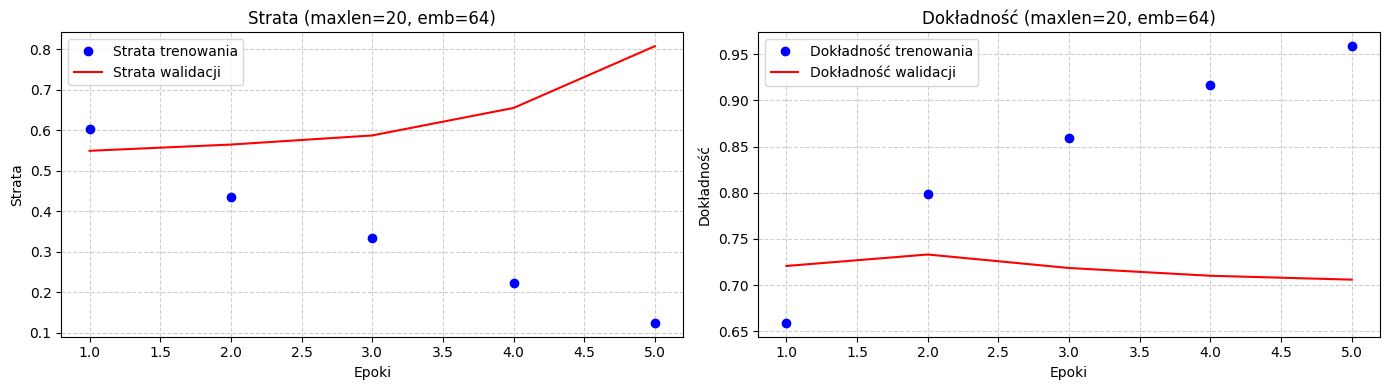

--- maxlen=50, emb_dim=8 ---


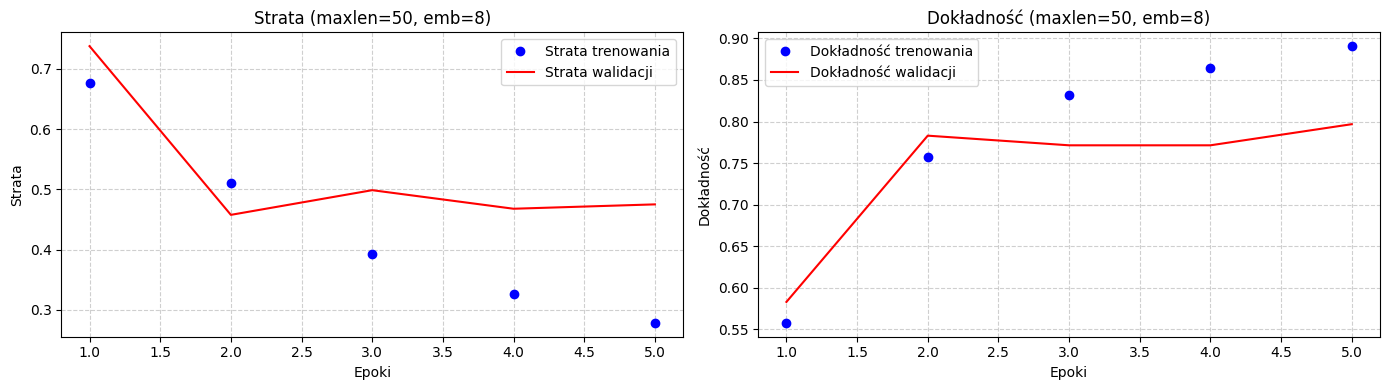

--- maxlen=50, emb_dim=32 ---


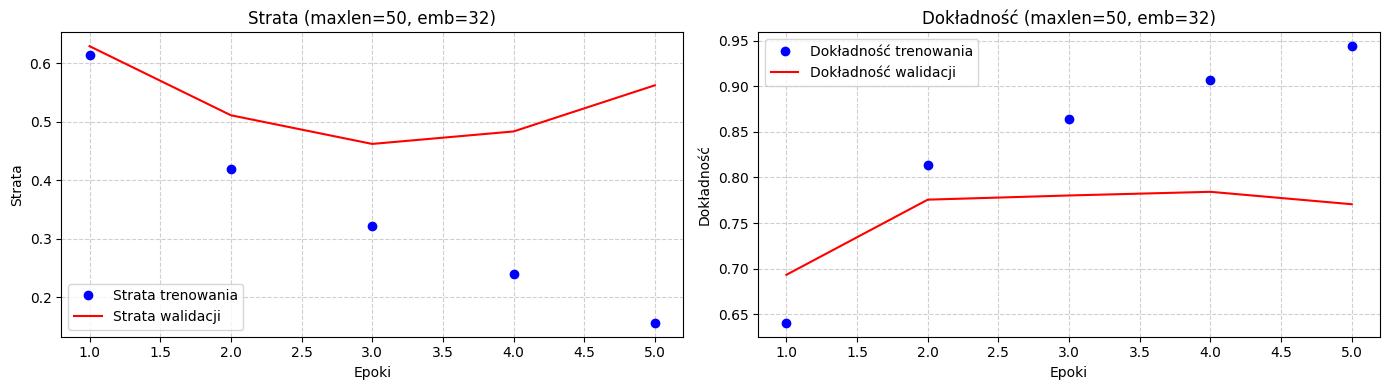

--- maxlen=50, emb_dim=64 ---


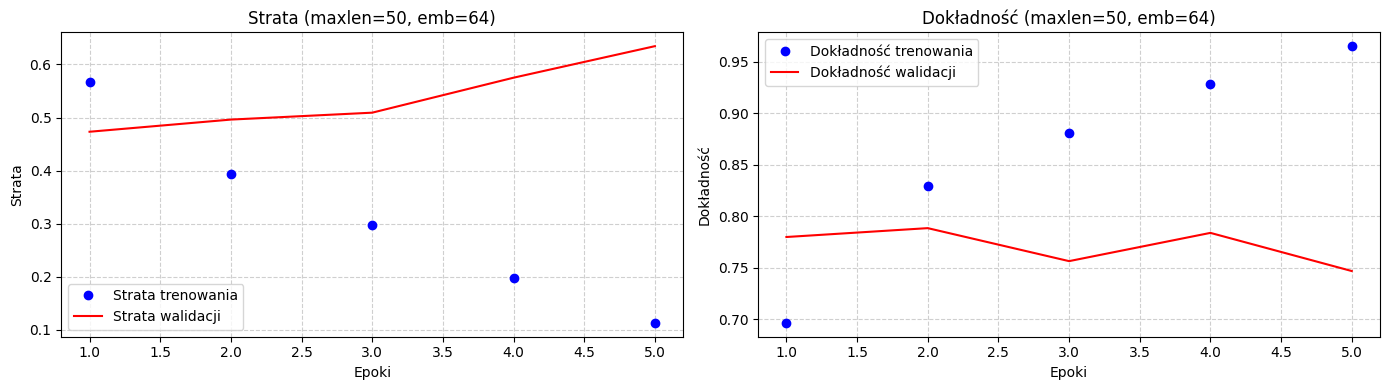

--- maxlen=100, emb_dim=8 ---


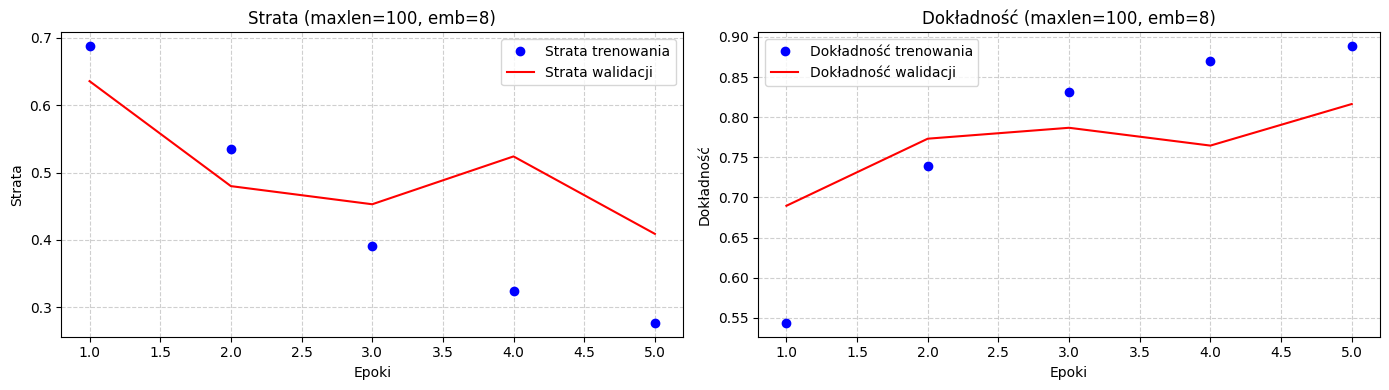

--- maxlen=100, emb_dim=32 ---


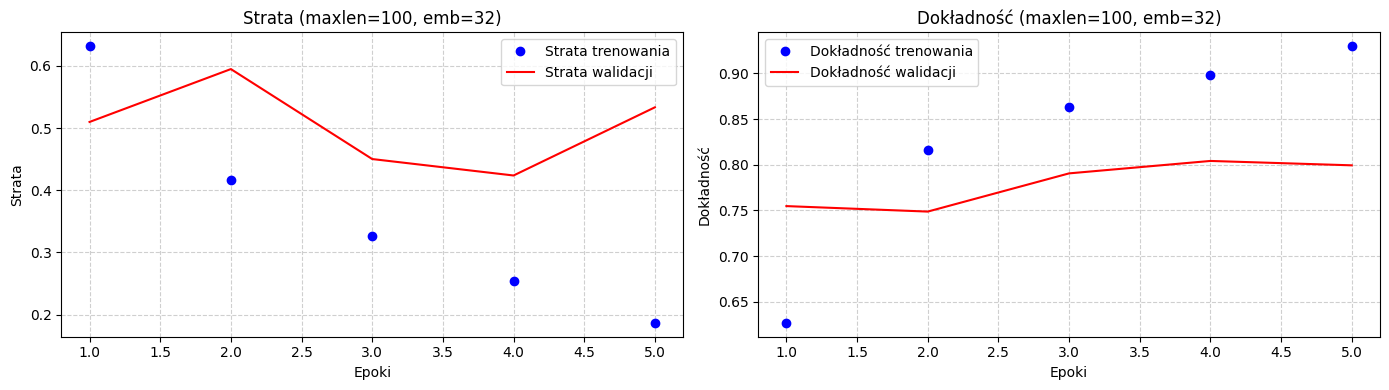

--- maxlen=100, emb_dim=64 ---


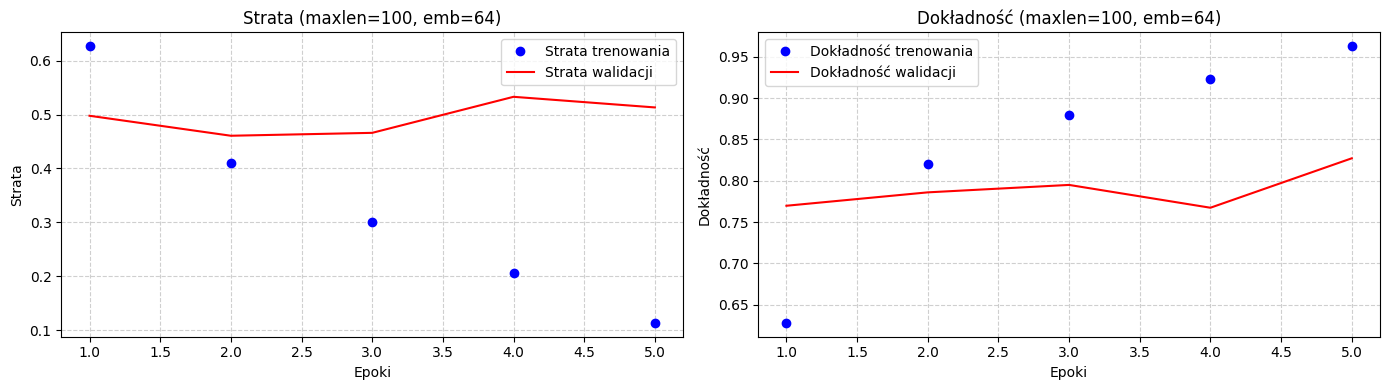

--- maxlen=200, emb_dim=8 ---


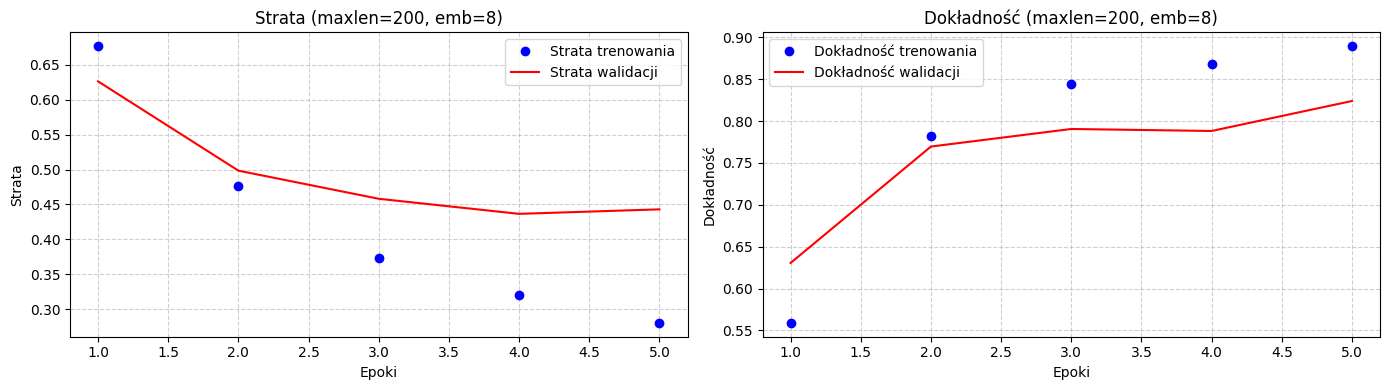

--- maxlen=200, emb_dim=32 ---


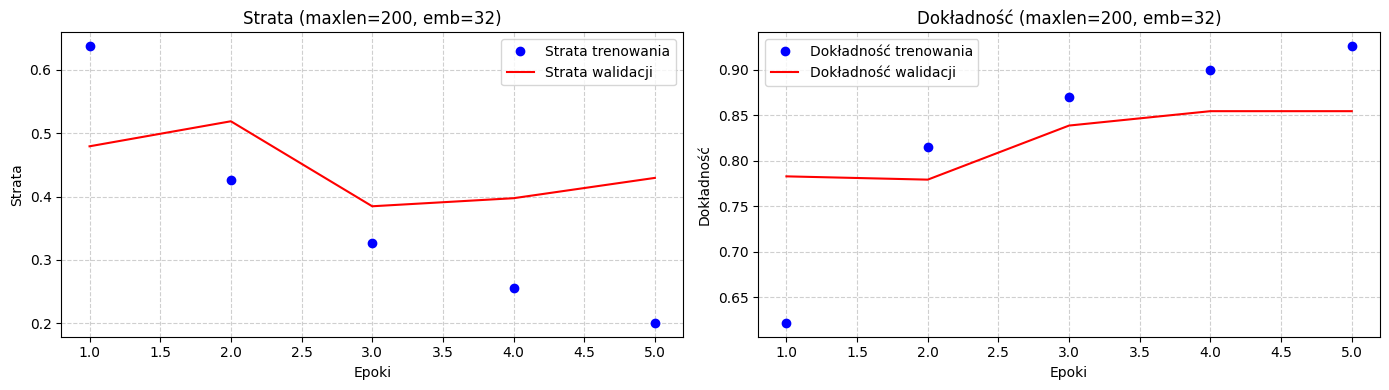

--- maxlen=200, emb_dim=64 ---


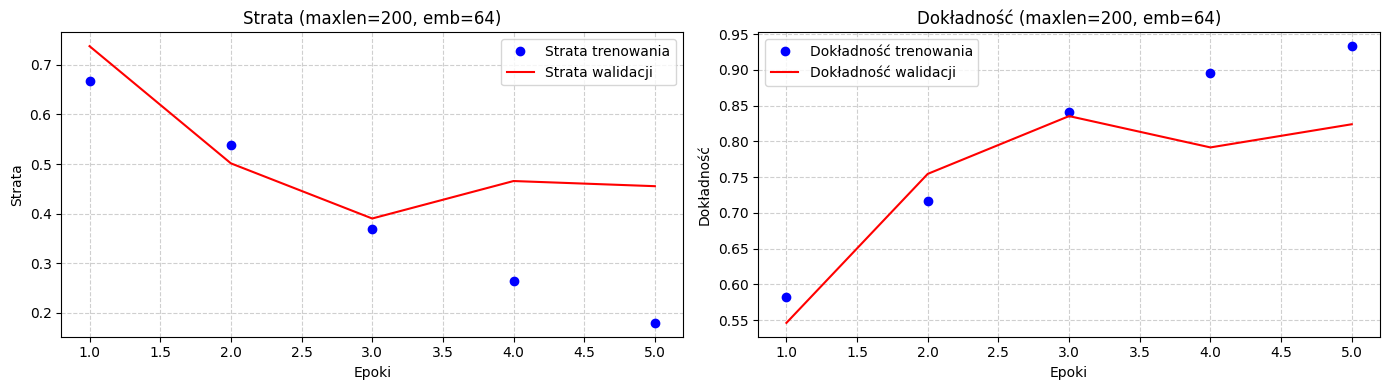

In [116]:
results = []

maxlen_values = [20, 50, 100, 200]
embedding_dims = [8, 32, 64]

for maxlen_test in maxlen_values:
    for emb_dim in embedding_dims:
        print(f"--- maxlen={maxlen_test}, emb_dim={emb_dim} ---")

        x_train_pad = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen_test)

        model_test = Sequential()
        model_test.add(Input(shape=(maxlen_test,)))
        model_test.add(Embedding(max_features, emb_dim))
        model_test.add(SimpleRNN(32))
        model_test.add(Dense(1, activation='sigmoid'))

        model_test.compile(optimizer='rmsprop',
                           loss='binary_crossentropy',
                           metrics=['acc'])

        history_test = model_test.fit(x_train_pad, y_train,
                                      epochs=5,
                                      batch_size=128,
                                      validation_split=0.2,
                                      verbose=0)

        acc = history_test.history['acc']
        val_acc = history_test.history['val_acc']
        loss = history_test.history['loss']
        val_loss = history_test.history['val_loss']
        epochs_range = range(1, len(acc) + 1)

        plt.figure(figsize=(14, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, loss, 'bo', label='Strata trenowania')
        plt.plot(epochs_range, val_loss, 'r-', label='Strata walidacji')
        plt.title(f'Strata (maxlen={maxlen_test}, emb={emb_dim})')
        plt.xlabel('Epoki')
        plt.ylabel('Strata')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, acc, 'bo', label='Dokładność trenowania')
        plt.plot(epochs_range, val_acc, 'r-', label='Dokładność walidacji')
        plt.title(f'Dokładność (maxlen={maxlen_test}, emb={emb_dim})')
        plt.xlabel('Epoki')
        plt.ylabel('Dokładność')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()

        final_val_acc = val_acc[-1]
        results.append({
            'maxlen': maxlen_test,
            'emb_dim': emb_dim,
            'val_acc': final_val_acc
        })

#### Podsumowanie wyników

In [117]:
results_sorted = sorted(results, key=lambda x: x['val_acc'], reverse=True)
for res in results_sorted:
    print(f"maxlen: {res['maxlen']:<4} | emb_dim: {res['emb_dim']:<3} | Dokładność walidacji: {res['val_acc']:.4f}")

maxlen: 200  | emb_dim: 32  | Dokładność walidacji: 0.8544
maxlen: 100  | emb_dim: 64  | Dokładność walidacji: 0.8272
maxlen: 200  | emb_dim: 8   | Dokładność walidacji: 0.8240
maxlen: 200  | emb_dim: 64  | Dokładność walidacji: 0.8240
maxlen: 100  | emb_dim: 8   | Dokładność walidacji: 0.8164
maxlen: 100  | emb_dim: 32  | Dokładność walidacji: 0.7994
maxlen: 50   | emb_dim: 8   | Dokładność walidacji: 0.7968
maxlen: 50   | emb_dim: 32  | Dokładność walidacji: 0.7706
maxlen: 50   | emb_dim: 64  | Dokładność walidacji: 0.7470
maxlen: 20   | emb_dim: 8   | Dokładność walidacji: 0.7340
maxlen: 20   | emb_dim: 32  | Dokładność walidacji: 0.7146
maxlen: 20   | emb_dim: 64  | Dokładność walidacji: 0.7060


#### Ćwiczenie 3 - Trenowanie warstwy LSTM

In [118]:
model_lstm = Sequential()
model_lstm.add(Input(shape=(maxlen,)))
model_lstm.add(Embedding(max_features, 32))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1, activation='sigmoid'))
model_lstm.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

In [119]:
print("Struktura LSTM:")
model_lstm.summary()

Struktura LSTM:


Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_43 (Embedding)        │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
# Trening
history_lstm = model_lstm.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - acc: 0.6615 - loss: 0.6047 - val_acc: 0.7814 - val_loss: 0.4653
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8271 - loss: 0.3985 - val_acc: 0.7898 - val_loss: 0.4705
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8635 - loss: 0.3289 - val_acc: 0.8504 - val_loss: 0.3511
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8798 - loss: 0.2939 - val_acc: 0.8236 - val_loss: 0.4197
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8852 - loss: 0.2836 - val_acc: 0.8710 - val_loss: 0.3050
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.9028 - loss: 0.2501 - val_acc: 0.7770 - val_loss: 0.4910
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.9115 - loss: 0.2290 - val_acc: 0.8734 - val_loss: 0.3203
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.9172 - loss: 0.2135 - val_acc: 0.8652 - val_loss: 0.3713
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/

In [121]:
acc = history_lstm.history['acc']
val_acc = history_lstm.history['val_acc']
loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']
epochs_range = range(1, len(acc) + 1)

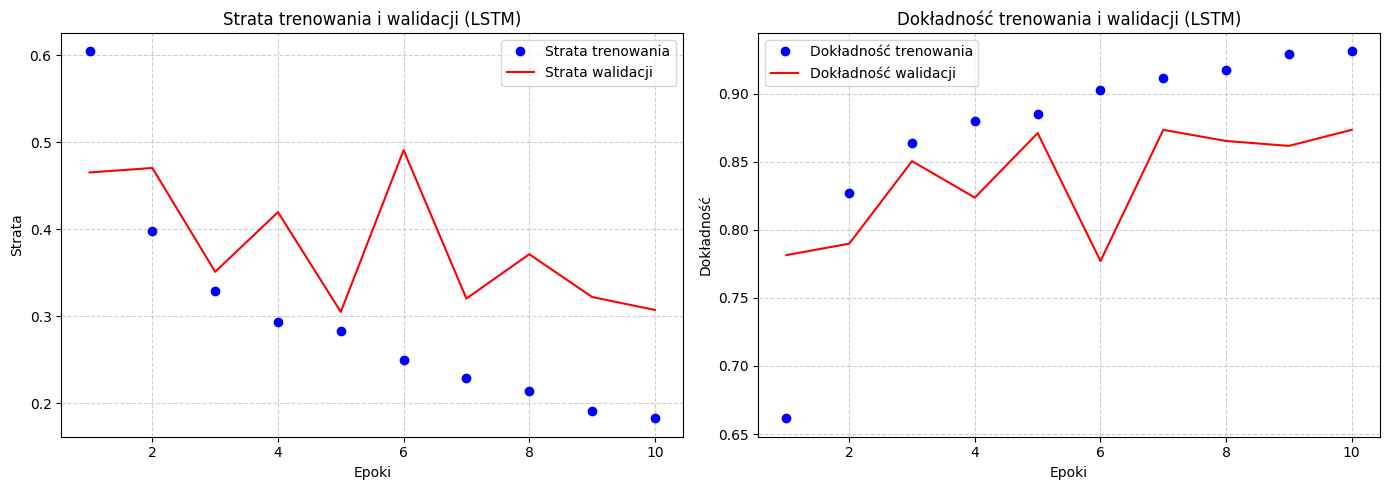

In [122]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'bo', label='Strata trenowania')
plt.plot(epochs_range, val_loss, 'r-', label='Strata walidacji')
plt.title('Strata trenowania i walidacji (LSTM)')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'bo', label='Dokładność trenowania')
plt.plot(epochs_range, val_acc, 'r-', label='Dokładność walidacji')
plt.title('Dokładność trenowania i walidacji (LSTM)')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Ćwiczenie 4 - Testowanie właściwości warstwy SimpleRNN i LSTM

In [123]:
# Test parametrów SimpleRNN
model_test_rnn = Sequential()
model_test_rnn.add(Input(shape=(10, 2)))
model_test_rnn.add(SimpleRNN(1))
print("\n--- Podsumowanie SimpleRNN ---")
model_test_rnn.summary()


--- Podsumowanie SimpleRNN ---


Model: "sequential_55"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_43 (SimpleRNN)       │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [124]:
# Test parametrów LSTM
model_test_lstm = Sequential()
model_test_lstm.add(Input(shape=(10, 2)))
model_test_lstm.add(LSTM(1))

In [125]:
print("\n--- Podsumowanie LSTM ---")
model_test_lstm.summary()


--- Podsumowanie LSTM ---


Model: "sequential_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

#### 1. Co oznaczają liczby 10 i 2 w input_shape=(10, 2)?
- 10 to liczba kroków czasowych (timesteps) - np. długość sekwencji.
- 2 to liczba cech na każdy krok czasowy.

#### 2. Czy kształt danych (input_shape) wpływa na ilość parametrów?
- Nie. Liczba parametrów w warstwach RNN/LSTM zależy tylko od liczby cech wejściowych oraz liczby jednostek w samej warstwie.